In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

In [2]:
# Cell 2: Load Data
# Read the dataset
df = pd.read_csv('CVD_cleaned.csv')

# Display the first few rows to verify it loaded correctly
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [3]:
# Cell 3: Data Preprocessing (Encoding and Scaling)
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns

# Encode categorical text data into numbers
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Separate features (X) and the target variable (y)
X = df.drop('General_Health', axis=1)
y = df['General_Health']

# Scale the features (Important for SVM and Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing complete. Data encoded and scaled.")

Preprocessing complete. Data encoded and scaled.


In [4]:
# Cell 4: Train-Test Split (8:2 ratio)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")

Training data shape (X_train): (247083, 18)
Testing data shape (X_test): (61771, 18)


In [5]:
# Cell 5: Initialize Accuracies Dictionary
accuracies = {}
print("Accuracy tracker initialized.")

Accuracy tracker initialized.


========== Logistic Regression ==========
Accuracy Score: 0.4247

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.13      0.20     11339
           1       0.37      0.13      0.19      7166
           2       0.41      0.44      0.42     18784
           3       0.40      0.05      0.09      2265
           4       0.44      0.70      0.54     22217

    accuracy                           0.42     61771
   macro avg       0.41      0.29      0.29     61771
weighted avg       0.42      0.42      0.38     61771



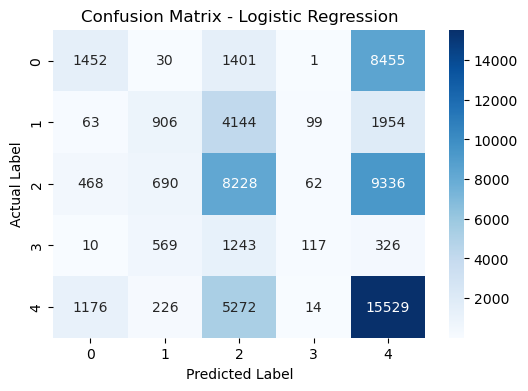

In [6]:
# Cell 6: Logistic Regression Model
print("========== Logistic Regression ==========")
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train and Predict
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Metrics
log_acc = accuracy_score(y_test, log_pred)
accuracies["Logistic Regression"] = log_acc
print(f"Accuracy Score: {log_acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, log_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

========== Random Forest ==========
Accuracy Score: 0.4067

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.24      0.30     11339
           1       0.33      0.18      0.23      7166
           2       0.39      0.46      0.42     18784
           3       0.32      0.08      0.13      2265
           4       0.44      0.55      0.49     22217

    accuracy                           0.41     61771
   macro avg       0.37      0.30      0.31     61771
weighted avg       0.40      0.41      0.39     61771



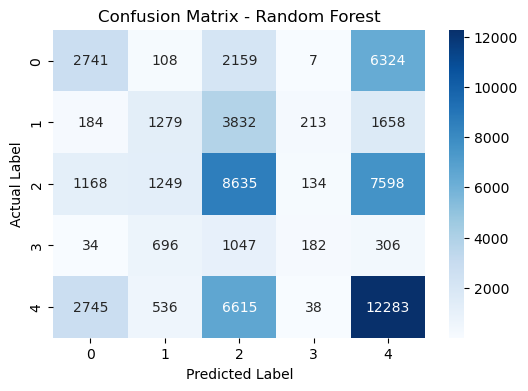

In [7]:
# Cell 7: Random Forest Model
print("========== Random Forest ==========")
rf_model = RandomForestClassifier(random_state=42)

# Train and Predict
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Metrics
rf_acc = accuracy_score(y_test, rf_pred)
accuracies["Random Forest"] = rf_acc
print(f"Accuracy Score: {rf_acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Cell 8: SVM Model (WARNING: May take a long time to execute)
print("========== Support Vector Machine (SVM) ==========")
svm_model = SVC(random_state=42)

# Train and Predict
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Metrics
svm_acc = accuracy_score(y_test, svm_pred)
accuracies["SVM"] = svm_acc
print(f"Accuracy Score: {svm_acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, svm_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

========== Support Vector Machine (SVM) ==========


In [ ]:
# Cell 9: Accuracy Comparison Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)

# Add exact values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f"{yval:.4f}", ha='center', fontweight='bold')

plt.show()

In [ ]:
# Cell 10: Hyperparameter Tuning (Random Forest)
print("Starting Randomised Grid Search for Random Forest...")

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Setup Randomized Search
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_distributions=param_dist, 
    n_iter=5,  # Number of parameter settings that are sampled
    cv=3,      # 3-fold cross-validation
    verbose=2, 
    random_state=42, 
    n_jobs=-1  # Use all available cores
)

# Fit the random search model
rf_random.fit(X_train, y_train)

print(f"\nBest Hyperparameters found: {rf_random.best_params_}")
best_model = rf_random.best_estimator_

# Evaluate the tuned model
best_pred = best_model.predict(X_test)
best_acc = accuracy_score(y_test, best_pred)
print(f"Tuned Model Accuracy: {best_acc:.4f}")

In [ ]:
# Cell 11: AI Health Prediction System Simulation
def ai_health_prediction(sample_index, model, scaler, encoder):
    print("\n" + "*"*50)
    print("      AI HEALTH PREDICTION SYSTEM      ")
    print("*"*50)
    
    # Extract a single sample from the original (unscaled) features
    sample_input = X.iloc[[sample_index]]
    actual_label_encoded = y.iloc[sample_index]
    
    # Scale the input using the fitted scaler
    sample_scaled = scaler.transform(sample_input)
    
    # Predict the outcome
    prediction_encoded = model.predict(sample_scaled)[0]
    
    # Decode numerical labels back to original text for readability
    predicted_health = encoder.inverse_transform([prediction_encoded])[0]
    actual_health = encoder.inverse_transform([actual_label_encoded])[0]
    
    print("\n[Patient Profile Data Received]")
    sample_dict = sample_input.to_dict('records')[0]
    for key, value in sample_dict.items():
        # Decode categorical features for display
        if key in label_encoders:
            try:
                val_decoded = label_encoders[key].inverse_transform([int(value)])[0]
                print(f" - {key}: {val_decoded}")
            except:
                print(f" - {key}: {value}")
        else:
            print(f" - {key}: {value}")
            
    print("-" * 50)
    print(f">> PREDICTED General Health Status : {predicted_health.upper()}")
    print(f">> ACTUAL General Health Record    : {actual_health.upper()}")
    print("*"*50 + "\n")

# Test the AI system with a patient from the dataset (e.g., patient at index 100)
ai_health_prediction(sample_index=100, model=best_model, scaler=scaler, encoder=label_encoders['General_Health'])
